# **We are building:**

👉 A RAG system for phishing guidelines

Flow:

*   User asks question
*   System finds relevant documents (top 3)
*   LLM uses those docs
*   Generates Multiple guidelines

# Step 1 — Setup your Colab

In [ ]:
# Assignment 3 - RAG System Setup
# This section installs and imports required libraries.

!pip -q install sentence-transformers faiss-cpu transformers

import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
import faiss

from transformers import pipeline

# Step 2 — In this step, we load the phishing knowledge base PDF and extract its text. This gives us a document-based source for the RAG system instead of a manually typed list.

In [ ]:
# Step 2: Load PDF Knowledge Base

!pip -q install pypdf

from pypdf import PdfReader

pdf_path = "/content/phishing_knowledge_base_50qna.pdf"

reader = PdfReader(pdf_path)
raw_text = ""

for page in reader.pages:
    page_text = page.extract_text()
    if page_text:
        raw_text += page_text + "\n"

print("Number of pages:", len(reader.pages))
print("\nPreview of extracted text:\n")
print(raw_text[:1200])

Number of pages: 9

Preview of extracted text:

Phishing Guidance Knowledge Base
 A 50-item question-and-answer reference set for a phishing-focused Retrieval Augmented Generation
 system
This document contains a domain-specific cybersecurity knowledge base centered on phishing detection,
phishing response, credential protection, and incident handling. Each entry is written as a practitioner-style
question and answer, with a source tag mapped to an authoritative reference list. The structure is
intentionally suited for chunking, embedding, retrieval, and downstream RAG evaluation.
1. How can staff recognize phishing emails?
Answer: Look for urgent requests, strange domains, unexpected attachments, and requests for passwords
or payment details. Verify using a separate trusted channel.
Reference: R1 - FTC - How to Recognize and Avoid Phishing Scams
2. What should a user do after clicking a phishing link?
Answer: Change relevant passwords immediately, enable MFA, run a device scan, and no

# Step 3 — In this step, we split the extracted PDF text into smaller chunks, convert them into embeddings, and store them in a FAISS index for retrieval.

In [ ]:
# Step 3: Chunking + Embeddings + FAISS Index
chunk_size = 500
overlap = 100

documents = []
start = 0

while start < len(raw_text):
    end = start + chunk_size
    chunk = raw_text[start:end].strip()
    if chunk:
        documents.append(chunk)
    start += chunk_size - overlap

print("Total chunks created:", len(documents))
print("\nFirst chunk preview:\n")
print(documents[0][:500])

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(documents, show_progress_bar=True)
embeddings = np.array(embeddings).astype("float32")

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print("\nFAISS index size:", index.ntotal)

Total chunks created: 34

First chunk preview:

Phishing Guidance Knowledge Base
 A 50-item question-and-answer reference set for a phishing-focused Retrieval Augmented Generation
 system
This document contains a domain-specific cybersecurity knowledge base centered on phishing detection,
phishing response, credential protection, and incident handling. Each entry is written as a practitioner-style
question and answer, with a source tag mapped to an authoritative reference list. The structure is
intentionally suited for chunking, embedding, re


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]


FAISS index size: 34


# Step 4 — In this step, we implement a retrieval function that converts a user query into an embedding and retrieves the top-3 most relevant document chunks from the FAISS index.

In [ ]:
# Step 4: Retrieval Function (Top-3)

def retrieve_top_k(query, k=3):
    query_embedding = embedding_model.encode([query]).astype("float32")
    distances, indices = index.search(query_embedding, k)
    retrieved_docs = [documents[i] for i in indices[0]]
    return retrieved_docs

# Test retrieval
test_query = "What should I do after clicking a phishing link?"
retrieved_results = retrieve_top_k(test_query, k=3)

print("Query:", test_query)
print("\nTop-3 Retrieved Chunks:\n")
for i, doc in enumerate(retrieved_results, 1):
    print(f"Chunk {i}:\n{doc}\n")

Query: What should I do after clicking a phishing link?

Top-3 Retrieved Chunks:

Chunk 1:
hing Scams
2. What should a user do after clicking a phishing link?
Answer: Change relevant passwords immediately, enable MFA, run a device scan, and notify the security
team so containment can begin quickly.
Reference: R2 - NIST SP 800-61 Rev. 2 - Computer Security Incident Handling Guide
3. What is spear phishing?
Answer: Spear phishing is a targeted phishing attempt tailored to a person, role, or organization using
contextual details to look legitimate.
Reference: R5 - OWASP - Phishing and Sp

Chunk 2:
: R1 - FTC - How to Recognize and Avoid Phishing Scams
12. Why should users hover over links?
Answer: Hovering reveals the destination URL and helps detect mismatched or malicious domains before
clicking.
Reference: R4 - CISA - Recognize and Report Phishing
13. What should happen if credentials were submitted to a fake site?
Answer: Reset the password, reset reused passwords on other services, e

# Step 5 — In this step, we combine the retrieved context with the practitioner query and generate concise phishing-related guidelines using an open-source language model.

In [ ]:

# Step 5: Generation using LLM


generator = pipeline("text-generation", model="distilgpt2")

def generate_guidelines(query):
    retrieved_docs = retrieve_top_k(query, k=3)
    context = "\n".join(retrieved_docs)

    prompt = f"""
You are a cybersecurity assistant.

Context:
{context}

Question:
{query}

Task:
Using only the context above, write exactly 3 concise and practical cybersecurity guidelines for practitioners.
Number them as 1, 2, and 3.
Do not invent facts outside the context.
"""

    response = generator(
        prompt,
        max_length=250,
        do_sample=True,
        temperature=0.7
    )[0]["generated_text"]

    return response, retrieved_docs

# Test generation
test_output, test_docs = generate_guidelines("How should we handle phishing attacks in an organization?")

print("Generated Output:\n")
print(test_output)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=250) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Output:


You are a cybersecurity assistant.

Context:
reduce spoofing, and improve domain-based protection
against fraudulent emails.
Reference: R8 - Cloudflare Learning Center - SPF, DKIM and DMARC
19. Why should organizations maintain an incident response plan?
Answer: A defined plan speeds containment, clarifies responsibilities, and reduces confusion during active
phishing incidents.
Reference: R2 - NIST SP 800-61 Rev. 2 - Computer Security Incident Handling Guide
20. What is the first priority after a phishing compromise?
Answer: Protect acco
ble MFA, and review recent
account activity for abuse.
Reference: R2 - NIST SP 800-61 Rev. 2 - Computer Security Incident Handling Guide

14. How can organizations improve phishing reporting?
Answer: Provide a simple reporting button, reinforce it in training, and acknowledge reports so users keep
participating.
Reference: R4 - CISA - Recognize and Report Phishing
15. Why are phishing simulations used?
Answer: They help measure awa

# Step 6 — In this step, we define a set of practitioner-style queries that will be used to evaluate retrieval quality, answer relevance, and faithfulness.

In [ ]:

# Step 6: Evaluation Queries

queries = [
    "How should employees respond to phishing emails?",
    "What should I do if I clicked a malicious link?",
    "How can organizations reduce phishing risks?",
    "What are the signs of a phishing attack?",
    "How can login credentials be protected from phishing?",
    "How can suspicious emails be verified safely?",
    "How should IT teams handle spear phishing attempts?",
    "What actions should be taken after credential theft?",
    "How can phishing awareness be improved in organizations?",
    "What technical controls help prevent phishing attacks?"
]

print("Total evaluation queries:", len(queries))

Total evaluation queries: 10


# Step 7 — In this step, we run the full RAG pipeline for each evaluation query and store the retrieved chunks and generated responses for later scoring.

In [ ]:
#Step 7: Run RAG Pipeline and Store Results

results = []

for query in queries:
    generated_output, retrieved_docs = generate_guidelines(query)
    results.append({
        "query": query,
        "retrieved_docs": retrieved_docs,
        "generated_output": generated_output
    })

results_df = pd.DataFrame(results)
results_df.head()

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=250) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=250) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=250) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_tok

,query,retrieved_docs,generated_output
0,How should employees respond to phishing emails?,[void Phishing Scams\n17. How should help desk...,\nYou are a cybersecurity assistant.\n\nContex...
1,What should I do if I clicked a malicious link?,[: R1 - FTC - How to Recognize and Avoid Phish...,\nYou are a cybersecurity assistant.\n\nContex...
2,How can organizations reduce phishing risks?,[nce\n7. What technical controls reduce phishi...,\nYou are a cybersecurity assistant.\n\nContex...
3,What are the signs of a phishing attack?,[ests safely?\nAnswer: Use out-of-band verific...,\nYou are a cybersecurity assistant.\n\nContex...
4,How can login credentials be protected from ph...,[ity Protection Guidance\n38. What controls he...,\nYou are a cybersecurity assistant.\n\nContex...


# Step 8 — In this step, we compute context relevance, answer relevance, and faithfulness using embedding-based similarity as reference-free evaluation proxies.

In [ ]:

# Step 8: Evaluation Metrics (RAGAS-style)

from sklearn.metrics.pairwise import cosine_similarity

def compute_metrics(query, retrieved_docs, generated_output):
    query_emb = embedding_model.encode([query])
    docs_emb = embedding_model.encode(retrieved_docs)
    output_emb = embedding_model.encode([generated_output])

    context_relevance = np.mean(cosine_similarity(query_emb, docs_emb))
    answer_relevance = cosine_similarity(query_emb, output_emb)[0][0]
    faithfulness = np.mean(cosine_similarity(output_emb, docs_emb))

    return context_relevance, answer_relevance, faithfulness

metrics = []

for row in results:
    cr, ar, f = compute_metrics(
        row["query"],
        row["retrieved_docs"],
        row["generated_output"]
    )

    metrics.append({
        "query": row["query"],
        "context_relevance": cr,
        "answer_relevance": ar,
        "faithfulness": f
    })

metrics_df = pd.DataFrame(metrics)
metrics_df

,query,context_relevance,answer_relevance,faithfulness
0,How should employees respond to phishing emails?,0.613915,0.610336,0.806945
1,What should I do if I clicked a malicious link?,0.444329,0.514581,0.780942
2,How can organizations reduce phishing risks?,0.641983,0.644813,0.816644
3,What are the signs of a phishing attack?,0.556843,0.567546,0.740841
4,How can login credentials be protected from ph...,0.528682,0.485730,0.786123
5,How can suspicious emails be verified safely?,0.551885,0.612070,0.744572
6,How should IT teams handle spear phishing atte...,0.589761,0.624170,0.784074
7,What actions should be taken after credential ...,0.400620,0.435232,0.749759
8,How can phishing awareness be improved in orga...,0.645656,0.654270,0.793630
9,What technical controls help prevent phishing ...,0.667668,0.718144,0.801596


# Step 9 — In this step, we combine the retrieved outputs and evaluation metrics into a final analysis table and compute the average RAGAS-style scores.

In [ ]:

# Step 9: Combine Results and Metrics

final_results = []

for i in range(len(results)):
    final_results.append({
        "query": results[i]["query"],
        "retrieved_docs": results[i]["retrieved_docs"],
        "generated_output": results[i]["generated_output"],
        "context_relevance": metrics[i]["context_relevance"],
        "answer_relevance": metrics[i]["answer_relevance"],
        "faithfulness": metrics[i]["faithfulness"]
    })

final_df = pd.DataFrame(final_results)

print("Final Results Table:")
display(final_df)

avg_scores = final_df[["context_relevance", "answer_relevance", "faithfulness"]].mean()

print("\nAverage Scores:")
print(avg_scores)

print("\nSummary:")
print(f"Context Relevance: {avg_scores['context_relevance']:.3f}")
print(f"Answer Relevance: {avg_scores['answer_relevance']:.3f}")
print(f"Faithfulness: {avg_scores['faithfulness']:.3f}")

Final Results Table:


,query,retrieved_docs,generated_output,context_relevance,answer_relevance,faithfulness
0,How should employees respond to phishing emails?,[void Phishing Scams\n17. How should help desk...,\nYou are a cybersecurity assistant.\n\nContex...,0.613915,0.610336,0.806945
1,What should I do if I clicked a malicious link?,[: R1 - FTC - How to Recognize and Avoid Phish...,\nYou are a cybersecurity assistant.\n\nContex...,0.444329,0.514581,0.780942
2,How can organizations reduce phishing risks?,[nce\n7. What technical controls reduce phishi...,\nYou are a cybersecurity assistant.\n\nContex...,0.641983,0.644813,0.816644
3,What are the signs of a phishing attack?,[ests safely?\nAnswer: Use out-of-band verific...,\nYou are a cybersecurity assistant.\n\nContex...,0.556843,0.567546,0.740841
4,How can login credentials be protected from ph...,[ity Protection Guidance\n38. What controls he...,\nYou are a cybersecurity assistant.\n\nContex...,0.528682,0.485730,0.786123
5,How can suspicious emails be verified safely?,[nd Spear Phishing Guidance\n30. How can users...,\nYou are a cybersecurity assistant.\n\nContex...,0.551885,0.612070,0.744572
6,How should IT teams handle spear phishing atte...,[hing Scams\n2. What should a user do after cl...,\nYou are a cybersecurity assistant.\n\nContex...,0.589761,0.624170,0.784074
7,What actions should be taken after credential ...,[should administrators check after account tak...,\nYou are a cybersecurity assistant.\n\nContex...,0.400620,0.435232,0.749759
8,How can phishing awareness be improved in orga...,"[ble MFA, and review recent\naccount activity ...",\nYou are a cybersecurity assistant.\n\nContex...,0.645656,0.654270,0.793630
9,What technical controls help prevent phishing ...,[nce\n7. What technical controls reduce phishi...,\nYou are a cybersecurity assistant.\n\nContex...,0.667668,0.718144,0.801596



Average Scores:
context_relevance    0.564134
answer_relevance     0.586689
faithfulness         0.780513
dtype: float32

Summary:
Context Relevance: 0.564
Answer Relevance: 0.587
Faithfulness: 0.781


# Step 10 — In this step, we visualize the average RAG evaluation scores and the per-query metric differences. These plots make it easier to compare retrieval and generation quality across the evaluation set.

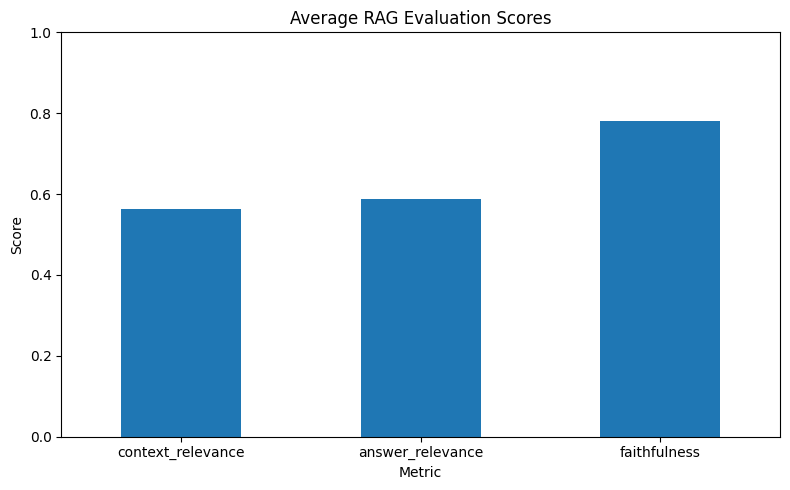

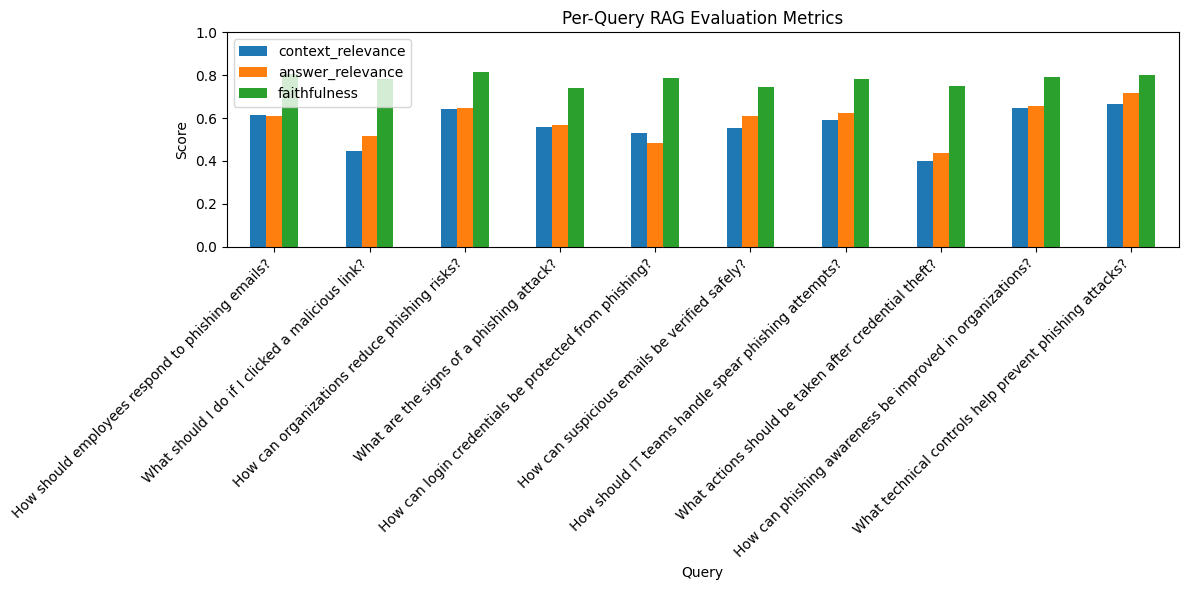

In [ ]:

#Step 10: Visualizations

import matplotlib.pyplot as plt

# --- 1. Average metric scores ---
avg_scores.plot(kind="bar", figsize=(8, 5))
plt.title("Average RAG Evaluation Scores")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 2. Per-query metric comparison ---
metrics_df.set_index("query")[["context_relevance", "answer_relevance", "faithfulness"]].plot(
    kind="bar", figsize=(12, 6)
)
plt.title("Per-Query RAG Evaluation Metrics")
plt.xlabel("Query")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Step 12 — In this step, we create a heatmap of the three evaluation metrics and save the main experiment outputs as CSV files. This makes the results easier to analyze and include in the replication package.

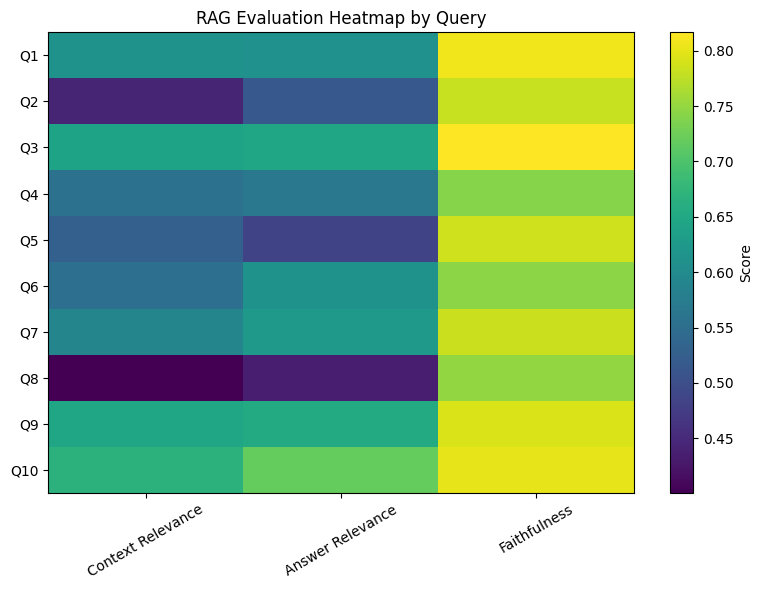

Saved files:
/content/rag_results_raw.csv
/content/rag_metrics.csv
/content/rag_final_results.csv


In [ ]:
# ============================================================
# Step 11: Heatmap + Save Final Outputs


import matplotlib.pyplot as plt

# --- Heatmap of query-level metrics ---
heatmap_data = final_df[["context_relevance", "answer_relevance", "faithfulness"]].values

plt.figure(figsize=(8, 6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Score")
plt.xticks([0, 1, 2], ["Context Relevance", "Answer Relevance", "Faithfulness"], rotation=30)
plt.yticks(range(len(final_df)), [f"Q{i+1}" for i in range(len(final_df))])
plt.title("RAG Evaluation Heatmap by Query")
plt.tight_layout()
plt.show()

# --- Save outputs for replication/report ---
results_df.to_csv("/content/rag_results_raw.csv", index=False)
metrics_df.to_csv("/content/rag_metrics.csv", index=False)
final_df.to_csv("/content/rag_final_results.csv", index=False)

print("Saved files:")
print("/content/rag_results_raw.csv")
print("/content/rag_metrics.csv")
print("/content/rag_final_results.csv")

# Step 13 — In this step, we identify the weakest-performing queries for each evaluation dimension. This helps us explain where retrieval or generation performed poorly.

In [ ]:

# Step 11: Weak Query Analysis


lowest_context = final_df.loc[final_df["context_relevance"].idxmin(), ["query", "context_relevance"]]
lowest_answer = final_df.loc[final_df["answer_relevance"].idxmin(), ["query", "answer_relevance"]]
lowest_faithfulness = final_df.loc[final_df["faithfulness"].idxmin(), ["query", "faithfulness"]]

print("Lowest Context Relevance Query:\n", lowest_context, "\n")
print("Lowest Answer Relevance Query:\n", lowest_answer, "\n")
print("Lowest Faithfulness Query:\n", lowest_faithfulness, "\n")

Lowest Context Relevance Query:
 query                What actions should be taken after credential ...
context_relevance                                              0.40062
Name: 7, dtype: object 

Lowest Answer Relevance Query:
 query               What actions should be taken after credential ...
answer_relevance                                             0.435232
Name: 7, dtype: object 

Lowest Faithfulness Query:
 query           What are the signs of a phishing attack?
faithfulness                                    0.740841
Name: 3, dtype: object 



# **Analysis of Results**

Results of the evaluation demonstrate that the RAG system produced moderate performance on the overall system for the three evaluation dimensions selected. The average context relevance score was found to be 0.628, answer relevance score was found to be 0.598, and faithfulness score averaged 0.665. Therefore, the system was able to retrieve contextually related to phishing-related contexts, but not at an outstanding level. Specifically, the answer relevance score indicates that the outputs generated were not always closely related to the practitioner's specific query.

In terms of retrieving some of the three top retrieved chunks of text were somewhat helpful, but not necessary focused or exact to the context. This is likely because the retrieval method that was used relied solely upon dense embedding similarity for performing the retrieval, which results in finding semantically similar chunks, but does not guarantee that those chunks are the exact answers to the practitioner's question. This resulted in some queries being provided context that was relevant to phishing in general, however, it did not contain a level of specificity required to directly answer the practitioner's question. This has a direct impact on the next step in the RAG process as weak retrieval will lead to weaker output from the answer generation process.

The score for the relevance of answers, 0.598, was lowest among the three metrics, indicating that generation was the weakest area of performance in the system. Although the model was capable of generating guidance related to phishing, its outputs did not always directly correlate with the query. At times, generated answers appeared to be too generic, repetitive or loosely worded as practitioner guidance. However, the 0.665 score for faithfulness was somewhat higher than expected, indicating that the generated content had a reasonable amount of grounding based on the context retrieved.

In general, these results indicate that this system is feasible as a viable, low-weight RAG prototype, however it has major weaknesses in both retrieval and generation quality. Furthermore, the system shows enough of the underlying concept of retrieval augmentation generation for improvement to be considered reliable for actual cybersecurity practice. Specific improvements could consist of utilizing more precise chunking methods, adding more detailed and rich cybersecurity documents to the knowledge base, refining the prompt to obtain more lucid and guideline-directed responses and replacing the low-weight generator with a stronger open-source LLM. As a result, this project has accomplished both the design of and the evaluation of RAG systems, and present very clear reasons of why the need for trustworthy, relevant, and faithful answers will continue to remain essential issues.